# Загрузка и анализ данных

Скачаем необходимые библиотеки

In [ ]:
!pip install -q catboost category-encoders optuna phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 6.5 MB/s eta 0:00:00


Импортируем необходимые библиотеки

In [ ]:
import numpy as np
import polars as pl

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    auc,
    ConfusionMatrixDisplay,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from category_encoders import CatBoostEncoder, CountEncoder

import phik

from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import ClusterCentroids

from catboost import CatBoostClassifier

from optuna import create_study
from optuna.logging import set_verbosity, WARNING
from optuna.samplers import TPESampler

from torch import cuda

from scipy.special import expit

from warnings import filterwarnings
filterwarnings('ignore')

random_state = 42

Прочитаем наш датасет - это искусственно сгенерированные данные о транзакциях, осуществляемых с помощью банковских карт. Опишем признаки:
- type - тип транзакции. Всего их существует 5 видов:
   - CASH_IN - внесение наличных денег на виртуальный счёт
   - CASH_OUT - снятие наличных денег с виртуального счёта
   - DEBIT - дебетовый платёж
   - PAYMENT - платёж с возможной выдачей кредитных средств
   - TRANSFER - перевод деежнывх средств с одной карты на другую
- amount - сумма транзакции
- nameOrig - номер карты отправителя
- oldbalanceOrig - баланс карты отправителя до транзакции
- newbalanceOrig - баланс карты отправителя после транзакции
- nameDest - номер карты получателя
- oldbalanceDest - баланс карты получателя до транзакции
- newbalanceDest - баланс карты получателя после транзакции
- isFraud - является ли транзакция мошеннической
- isFlaggedFraud - пометила ли некая система транзакцию как мошенническую

Смысл данной работы заключается в поиске мошеннических транзакций

In [ ]:
df = pl.read_csv('AIML Dataset.csv')
df = df.rename({'oldbalanceOrg': 'oldbalanceOrig'})
df = df.drop('step')
df

type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
str,f64,str,f64,f64,str,f64,f64,i64,i64
"""PAYMENT""",9839.64,"""C1231006815""",170136.0,160296.36,"""M1979787155""",0.0,0.0,0,0
"""PAYMENT""",1864.28,"""C1666544295""",21249.0,19384.72,"""M2044282225""",0.0,0.0,0,0
"""TRANSFER""",181.0,"""C1305486145""",181.0,0.0,"""C553264065""",0.0,0.0,1,0
"""CASH_OUT""",181.0,"""C840083671""",181.0,0.0,"""C38997010""",21182.0,0.0,1,0
"""PAYMENT""",11668.14,"""C2048537720""",41554.0,29885.86,"""M1230701703""",0.0,0.0,0,0
…,…,…,…,…,…,…,…,…,…
"""CASH_OUT""",339682.13,"""C786484425""",339682.13,0.0,"""C776919290""",0.0,339682.13,1,0
"""TRANSFER""",6.3114e6,"""C1529008245""",6.3114e6,0.0,"""C1881841831""",0.0,0.0,1,0
"""CASH_OUT""",6.3114e6,"""C1162922333""",6.3114e6,0.0,"""C1365125890""",68488.84,6.3799e6,1,0


Напишем функцию для отрисовки круговых диаграмм для категориальных признаков

In [ ]:
def pie_plot(df, column, autopct='%1.1f%%', figsize=(6, 6)):
    vc = df[column].value_counts()
    labels = list(vc[column])
    sizes = list(vc['count'])
    ax = plt.subplots(figsize=figsize)[1]
    ax.pie(sizes, autopct=autopct, labels=labels)
    ax.set_title(column)
    plt.show()

Посмотрим на распределение целевой переменной

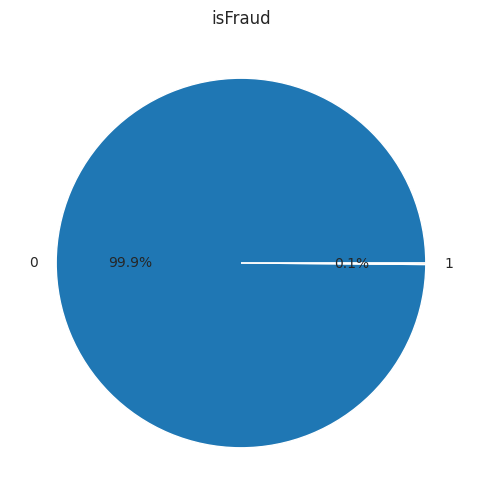

In [ ]:
pie_plot(df, 'isFraud')

Меньше одной десятой процента - значит при обучении моделей надо будет использовать инструменты для борьбы с дизбалансом классов

Добавим следующие новые признаки:
- Разность между старым и новым балансами отправителя
- Разность между новым и старым балансом получателя

In [ ]:
df.insert_column(
    df.columns.index('newbalanceOrig') + 1,
    pl.Series(
        'balanceDifferenceOrig',
        df['oldbalanceOrig'] - df['newbalanceOrig']
    )
)
df.insert_column(
    df.columns.index('newbalanceDest') + 1,
    pl.Series(
        'balanceDifferenceDest',
        df['newbalanceDest'] - df['oldbalanceDest']
    )
)

type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,balanceDifferenceOrig,nameDest,oldbalanceDest,newbalanceDest,balanceDifferenceDest,isFraud,isFlaggedFraud
str,f64,str,f64,f64,f64,str,f64,f64,f64,i64,i64
"""PAYMENT""",9839.64,"""C1231006815""",170136.0,160296.36,9839.64,"""M1979787155""",0.0,0.0,0.0,0,0
"""PAYMENT""",1864.28,"""C1666544295""",21249.0,19384.72,1864.28,"""M2044282225""",0.0,0.0,0.0,0,0
"""TRANSFER""",181.0,"""C1305486145""",181.0,0.0,181.0,"""C553264065""",0.0,0.0,0.0,1,0
"""CASH_OUT""",181.0,"""C840083671""",181.0,0.0,181.0,"""C38997010""",21182.0,0.0,-21182.0,1,0
"""PAYMENT""",11668.14,"""C2048537720""",41554.0,29885.86,11668.14,"""M1230701703""",0.0,0.0,0.0,0,0
…,…,…,…,…,…,…,…,…,…,…,…
"""CASH_OUT""",339682.13,"""C786484425""",339682.13,0.0,339682.13,"""C776919290""",0.0,339682.13,339682.13,1,0
"""TRANSFER""",6.3114e6,"""C1529008245""",6.3114e6,0.0,6.3114e6,"""C1881841831""",0.0,0.0,0.0,1,0
"""CASH_OUT""",6.3114e6,"""C1162922333""",6.3114e6,0.0,6.3114e6,"""C1365125890""",68488.84,6.3799e6,6.3114e6,1,0


Добавим признак того, является ли получатель торговцем. У торговцев первая буква номера карты - M

In [ ]:
df.insert_column(
    df.columns.index('nameDest') + 1,
    pl.Series('isDestMerchant', [0] * df.shape[0])
)
df = df.with_columns(
    pl.when(pl.col('nameDest').str.starts_with('M'))
      .then(1)
      .otherwise(pl.col('isDestMerchant'))
      .alias('isDestMerchant')
)

Разделим выборку на тренировочную, валидационную и тестовую

In [ ]:
df_train_and_valid, df_test = train_test_split(
    df,
    test_size=0.2,
    stratify=df['isFraud'],
    shuffle=True,
    random_state=random_state
)
df_train, df_valid = train_test_split(
    df_train_and_valid,
    test_size=0.2,
    stratify=df_train_and_valid['isFraud'],
    shuffle=True,
    random_state=random_state
)

Посмотрим на распределение признака типа транзакции для выборок

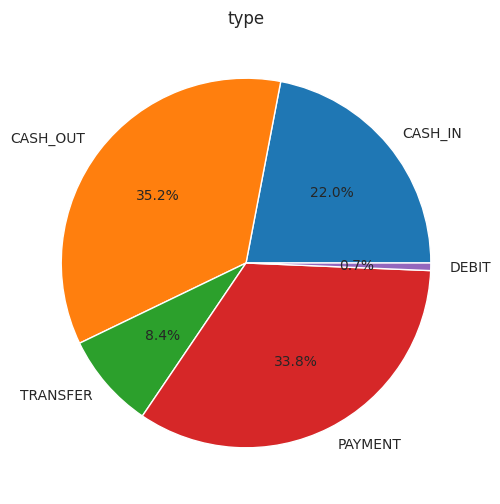

In [ ]:
pie_plot(df_train, 'type')

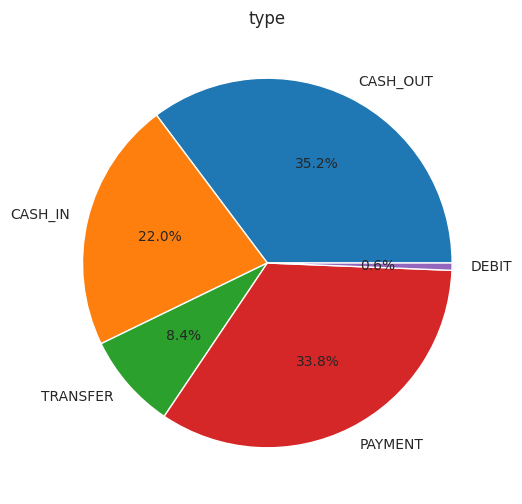

In [ ]:
pie_plot(df_valid, 'type')

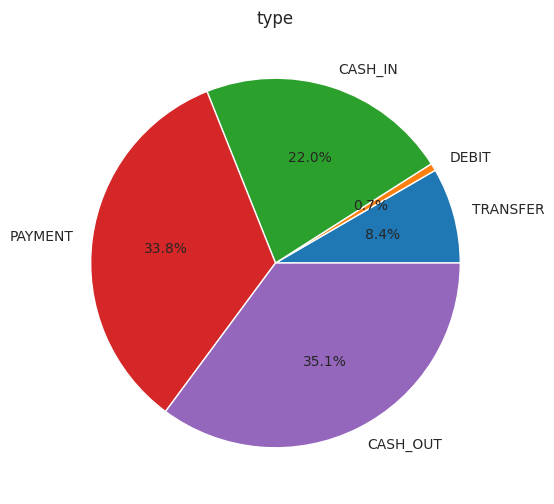

In [ ]:
pie_plot(df_test, 'type')

Видим, что распределения признака почти полностью совпадают друг с другом

Итак, посмотрим, сколько мошеннических транзакций в тренировочной выборке

In [ ]:
df_train.filter(pl.col('isFraud') == 1)['type'].value_counts()

type,count
str,u32
"""TRANSFER""",2626
"""CASH_OUT""",2630


Поисследовав данные (и тренировочные, и валидационные, и тестовые), я пришёл к выводу, что у мошеннических транзакций тип это либо перевод (TRANSFER), либо снятие наличных денег (CASH_OUT) - это уже важное наблюдение

Очень ярким признаком мошеннической транзакции при переводе оказались следующие условия:
- Размер транзакции равен разности между старым и новым балансами отправителя
- Старый и новый балансы получателя при этом равняются нулю

Посмотрим, сколько среди таких транзакций обычных

In [ ]:
df_train.filter(
    (pl.col('isFraud') == 0) & \
    (pl.col('type') == 'TRANSFER') & \
    (
        pl.col('amount') == pl.col('oldbalanceOrig') - pl.col('newbalanceOrig')
    ) & \
    (pl.col('oldbalanceDest') == 0) & \
    (pl.col('newbalanceDest') == 0)
)

type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,balanceDifferenceOrig,nameDest,isDestMerchant,oldbalanceDest,newbalanceDest,balanceDifferenceDest,isFraud,isFlaggedFraud
str,f64,str,f64,f64,f64,str,i64,f64,f64,f64,i64,i64
"""TRANSFER""",5795.42,"""C1104029235""",17377.0,11581.58,5795.42,"""C1054287225""",0,0.0,0.0,0.0,0,0
"""TRANSFER""",59270.81,"""C58808818""",120447.0,61176.19,59270.81,"""C1206178620""",0,0.0,0.0,0.0,0,0
"""TRANSFER""",143153.11,"""C1935319409""",539453.0,396299.89,143153.11,"""C534571065""",0,0.0,0.0,0.0,0,0
"""TRANSFER""",141027.88,"""C1439524983""",254411.0,113383.12,141027.88,"""C1387098908""",0,0.0,0.0,0.0,0,0
"""TRANSFER""",50519.28,"""C788003678""",77109.0,26589.72,50519.28,"""C425934297""",0,0.0,0.0,0.0,0,0
"""TRANSFER""",2717.54,"""C1806396673""",3016.0,298.46,2717.54,"""C1381058890""",0,0.0,0.0,0.0,0,0
"""TRANSFER""",243543.82,"""C476396120""",637975.0,394431.18,243543.82,"""C1957929104""",0,0.0,0.0,0.0,0,0


Итак, всего 7, а сколько же мошеннических?

In [ ]:
df_train.filter(
    (pl.col('isFraud') == 1) & \
    (pl.col('type') == 'TRANSFER') & \
    (
        pl.col('amount') == pl.col('oldbalanceOrig') - pl.col('newbalanceOrig')
    ) & \
    (pl.col('oldbalanceDest') == 0) & \
    (pl.col('newbalanceDest') == 0)
)

type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,balanceDifferenceOrig,nameDest,isDestMerchant,oldbalanceDest,newbalanceDest,balanceDifferenceDest,isFraud,isFlaggedFraud
str,f64,str,f64,f64,f64,str,i64,f64,f64,f64,i64,i64
"""TRANSFER""",571163.03,"""C250523545""",571163.03,0.0,571163.03,"""C1652699189""",0,0.0,0.0,0.0,1,0
"""TRANSFER""",2.2717e6,"""C1103494239""",2.2717e6,0.0,2.2717e6,"""C416462822""",0,0.0,0.0,0.0,1,0
"""TRANSFER""",231978.48,"""C202278158""",231978.48,0.0,231978.48,"""C988859148""",0,0.0,0.0,0.0,1,0
"""TRANSFER""",227304.91,"""C472872329""",227304.91,0.0,227304.91,"""C819459156""",0,0.0,0.0,0.0,1,0
"""TRANSFER""",537641.8,"""C1552180409""",537641.8,0.0,537641.8,"""C638930766""",0,0.0,0.0,0.0,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""TRANSFER""",2.1982e6,"""C752563135""",2.1982e6,0.0,2.1982e6,"""C247007952""",0,0.0,0.0,0.0,1,0
"""TRANSFER""",171337.99,"""C239155420""",171337.99,0.0,171337.99,"""C780047306""",0,0.0,0.0,0.0,1,0
"""TRANSFER""",489514.32,"""C1398711376""",489514.32,0.0,489514.32,"""C910056711""",0,0.0,0.0,0.0,1,0


Ого, 2585! Это примерно $\large{\frac{2585}{2626} \approx 0.9843869}$, то таким условием было найдено примерно 98,5% мошеннических переводов



Теперь обратим свой взор на снятие наличных денег. Об мошенничестве сигнализируют следующие признаки:
- Размер транзакции равен разности старого и нового балансов получателя
- Новый баланс получателя равен 0

Посмотрим, сколько таких немошеннических транзакций

In [ ]:
df_train.filter(
    (pl.col('isFraud') == 0) & \
    (pl.col('type') == 'CASH_OUT') & \
    (
        pl.col('amount') == pl.col('oldbalanceOrig') - pl.col('newbalanceOrig')
    ) & \
    (pl.col('newbalanceOrig') == 0)
)

type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,balanceDifferenceOrig,nameDest,isDestMerchant,oldbalanceDest,newbalanceDest,balanceDifferenceDest,isFraud,isFlaggedFraud
str,f64,str,f64,f64,f64,str,i64,f64,f64,f64,i64,i64


А таких вообще нет. Ну ладно, а сколько мошеннических?

In [ ]:
df_train.filter(
    (pl.col('isFraud') == 1) & \
    (pl.col('type') == 'CASH_OUT') & \
    (
        pl.col('amount') == pl.col('oldbalanceOrig') - pl.col('newbalanceOrig')
    ) & \
    (pl.col('newbalanceOrig') == 0)
)

type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,balanceDifferenceOrig,nameDest,isDestMerchant,oldbalanceDest,newbalanceDest,balanceDifferenceDest,isFraud,isFlaggedFraud
str,f64,str,f64,f64,f64,str,i64,f64,f64,f64,i64,i64
"""CASH_OUT""",8111.09,"""C151901104""",8111.09,0.0,8111.09,"""C797070356""",0,0.0,8111.09,8111.09,1,0
"""CASH_OUT""",2.4244e6,"""C467492380""",2.4244e6,0.0,2.4244e6,"""C576226769""",0,509474.11,2.9339e6,2.4244e6,1,0
"""CASH_OUT""",357836.57,"""C198543509""",357836.57,0.0,357836.57,"""C824285986""",0,51217.85,409054.43,357836.58,1,0
"""CASH_OUT""",506867.52,"""C341811151""",506867.52,0.0,506867.52,"""C1795348373""",0,0.0,458682.99,458682.99,1,0
"""CASH_OUT""",1e7,"""C1440908860""",1e7,0.0,1e7,"""C1590217660""",0,377441.15,1.0377e7,1e7,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""CASH_OUT""",7.4841e6,"""C99129129""",7.4841e6,0.0,7.4841e6,"""C1179262893""",0,62896.23,7.5470e6,7.4841e6,1,0
"""CASH_OUT""",136245.39,"""C104137128""",136245.39,0.0,136245.39,"""C1483261155""",0,1.0800e6,1.2163e6,136245.39,1,0
"""CASH_OUT""",125464.42,"""C448860094""",125464.42,0.0,125464.42,"""C1332940364""",0,332131.92,457596.34,125464.42,1,0


2608, здорово. $\large{\frac{2608}{2630} \approx 0.991634981}$, то есть удалось отсечь более 99% мошеннических снятий наличности

Назовём наш новый изначально нулевой признак suspicious (подозрительный) и вставим единицы в найденные позиции по вышеописанным условиям

In [ ]:
def insert_suspicious(df):
    df.insert_column(
        df.columns.index('type') + 1,
        pl.Series('suspicious', [0] * df.shape[0])
    )
    df = df.with_columns(
        pl.when(
            (pl.col('type') == 'TRANSFER') & \
            (
                pl.col('amount') == \
                pl.col('oldbalanceOrig') - pl.col('newbalanceOrig')
            ) & \
            (pl.col('oldbalanceDest') == 0) & \
            (pl.col('newbalanceDest') == 0)
        ).then(1)
        .otherwise(pl.col('suspicious'))
        .alias('suspicious')
    )
    df = df.with_columns(
        pl.when(
            (pl.col('type') == 'CASH_OUT') & \
            (
                pl.col('amount') == \
                pl.col('oldbalanceOrig') - pl.col('newbalanceOrig')
            ) & \
            (pl.col('newbalanceOrig') == 0)
        ).then(1)
        .otherwise(pl.col('suspicious'))
        .alias('suspicious')
    )
    return df

In [ ]:
df_train = insert_suspicious(df_train)
df_valid = insert_suspicious(df_valid)
df_test = insert_suspicious(df_test)

Закодируем частотным кодировщиком признак карты получателя. При этом так как категорий много, то на валидацонной и тестовой выборках будет также много категорий, которые в тренировочной не встречались. Для этого из тренировочных количеств вхождения вычтем дополнительно 1, чтобы те категории, которые всетрчалис только 1 раз, имели нулевое значение

In [ ]:
count_encoder = CountEncoder()
countDestTrain = pl.Series(
    'countDest',
    count_encoder.fit_transform(
        df_train['nameDest'].to_pandas()
    ).values.ravel() - 1
)
countDestValid = pl.Series(
    'countDest',
    count_encoder.transform(df_valid['nameDest'].to_pandas()).values.ravel()
)
countDestTest = pl.Series(
    'countDest',
    count_encoder.transform(df_test['nameDest'].to_pandas()).values.ravel()
)

Также дополнительно удалим признак карты отправителя, так как там слишком много уникальных значений, а максимальное число раз, которое встречается какая-нибудь карта - 3

In [ ]:
df_train.insert_column(
    df_train.columns.index('nameDest') + 1,
    countDestTrain
)
df_train = df_train.drop(['nameOrig', 'nameDest'])

df_valid.insert_column(
    df_test.columns.index('nameDest') + 1,
    countDestValid
)
df_valid = df_valid.drop(['nameOrig', 'nameDest'])

df_test.insert_column(
    df_test.columns.index('nameDest') + 1,
    countDestTest
)
df_test = df_test.drop(['nameOrig', 'nameDest'])

Посмотрим на те транзакции, в которых значение признака isFlaggedFraud равняется 1, то есть некая система засекла по её мнению мошеннические транзакции

In [ ]:
df.filter(pl.col('isFlaggedFraud') == 1)

type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,balanceDifferenceOrig,nameDest,isDestMerchant,oldbalanceDest,newbalanceDest,balanceDifferenceDest,isFraud,isFlaggedFraud
str,f64,str,f64,f64,f64,str,i64,f64,f64,f64,i64,i64
"""TRANSFER""",4.9539e6,"""C728984460""",4.9539e6,4.9539e6,0.0,"""C639921569""",0,0.0,0.0,0.0,1,1
"""TRANSFER""",1.3430e6,"""C1100582606""",1.3430e6,1.3430e6,0.0,"""C1147517658""",0,0.0,0.0,0.0,1,1
"""TRANSFER""",536624.41,"""C1035541766""",536624.41,536624.41,0.0,"""C1100697970""",0,0.0,0.0,0.0,1,1
"""TRANSFER""",4.8922e6,"""C908544136""",4.8922e6,4.8922e6,0.0,"""C891140444""",0,0.0,0.0,0.0,1,1
"""TRANSFER""",1e7,"""C689608084""",1.9585e7,1.9585e7,0.0,"""C1392803603""",0,0.0,0.0,0.0,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""TRANSFER""",3.4410e6,"""C917414431""",3.4410e6,3.4410e6,0.0,"""C1082139865""",0,0.0,0.0,0.0,1,1
"""TRANSFER""",3.1711e6,"""C1892216157""",3.1711e6,3.1711e6,0.0,"""C1308068787""",0,0.0,0.0,0.0,1,1
"""TRANSFER""",1e7,"""C2140038573""",1.7316e7,1.7316e7,0.0,"""C1395467927""",0,0.0,0.0,0.0,1,1


Здесь в основном трансферы крупных сумм денег, которые до получателя не дошли. Чтобы использовать признак, добавим в suspicious единицы в тех местах, где isFlaggedFraud также имеет единичные значения, а после удалим этот признак

In [ ]:
df_train = df_train.with_columns(
    pl.when(pl.col('isFlaggedFraud') == 1).
    then(1).
    otherwise(pl.col('suspicious')).
    alias('suspicious')
)
df_valid = df_valid.with_columns(
    pl.when(pl.col('isFlaggedFraud') == 1).
    then(1).
    otherwise(pl.col('suspicious')).
    alias('suspicious')
)
df_test = df_test.with_columns(
    pl.when(pl.col('isFlaggedFraud') == 1).
    then(1).
    otherwise(pl.col('suspicious')).
    alias('suspicious')
)

In [ ]:
df_train = df_train.drop('isFlaggedFraud')
df_valid = df_valid.drop('isFlaggedFraud')
df_test = df_test.drop('isFlaggedFraud')

Напишем функцию для отрисовки тепловых карт нелинейной корреляции phik

In [ ]:
def plot_phik(phik_matrix, significance_matrix, figsize=(20, 5)):
    axes = plt.subplots(ncols=2, figsize=figsize)[1]
    sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu', ax=axes[0])
    sns.heatmap(
        significance_matrix,
        annot=True,
        fmt='.1f',
        cmap='Greens',
        ax=axes[1]
    )
    axes[0].set_title('Коэффициент Phik')
    axes[1].set_title('Значимость коэффициента Phik')
    plt.tight_layout()
    plt.show()

Выделим численные и категориальные столбцы

In [ ]:
categorical_columns = df_train.select(pl.selectors.string()).columns
number_columns = df.select(pl.selectors.numeric()).columns

Получим матрицы нелинейной корреляции для выборок и отрисуем их

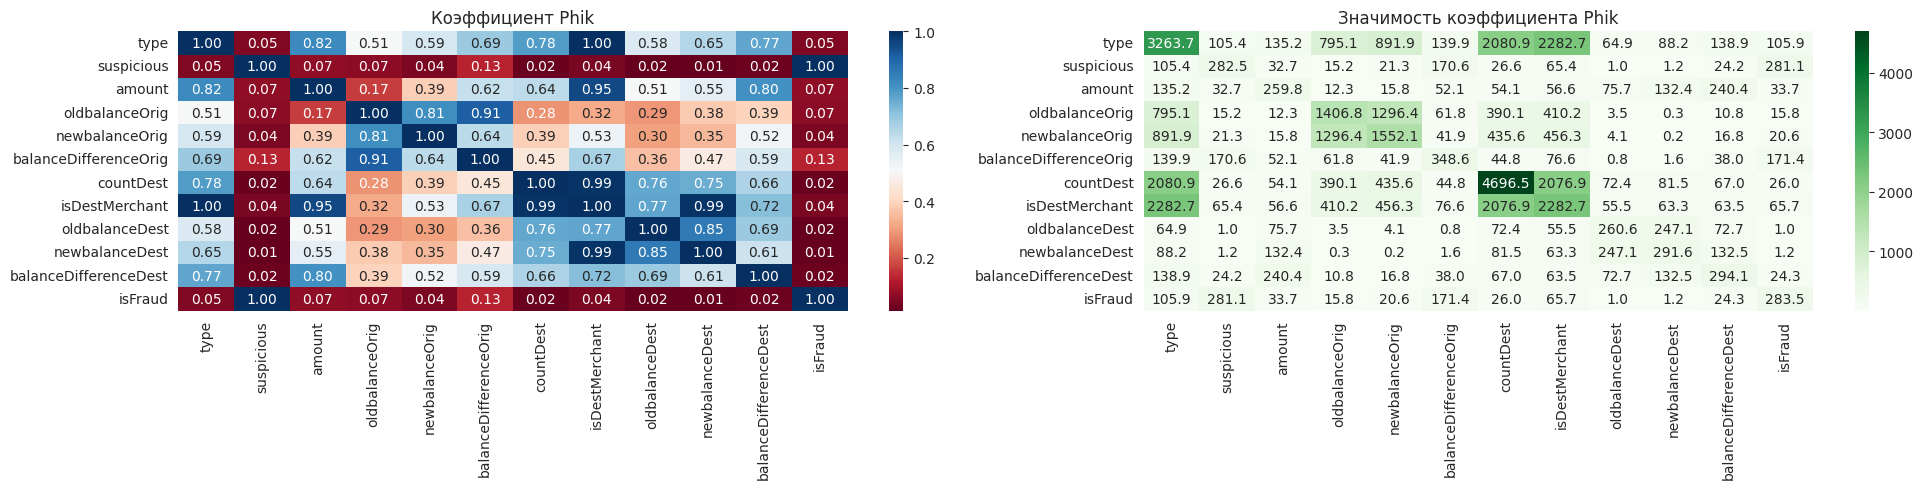

CPU times: user 1min 37s, sys: 7.13 s, total: 1min 45s
Wall time: 2min 56s


In [ ]:
%%time
df_train_pandas = df_train.to_pandas()
phik_matrix_train = df_train_pandas.phik_matrix(
    interval_cols=number_columns,
    quantile=True
)
significance_matrix_train = df_train_pandas.significance_matrix(
    interval_cols=number_columns
)
plot_phik(phik_matrix_train, significance_matrix_train)

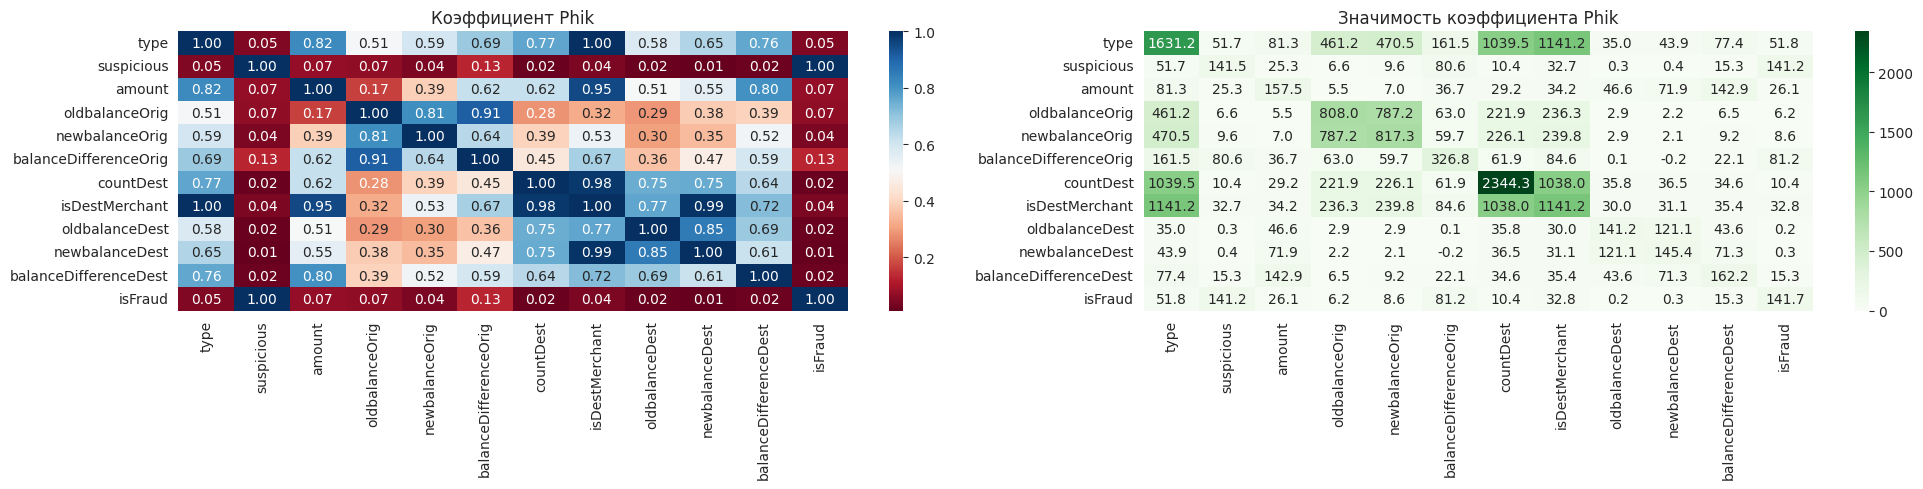

CPU times: user 28.8 s, sys: 1.42 s, total: 30.2 s
Wall time: 1min 10s


In [ ]:
%%time
df_valid_pandas = df_valid.to_pandas()
phik_matrix_valid = df_valid_pandas.phik_matrix(
    interval_cols=number_columns,
    quantile=True
)
significance_matrix_valid = df_valid_pandas.significance_matrix(
    interval_cols=number_columns
)
plot_phik(phik_matrix_valid, significance_matrix_valid)

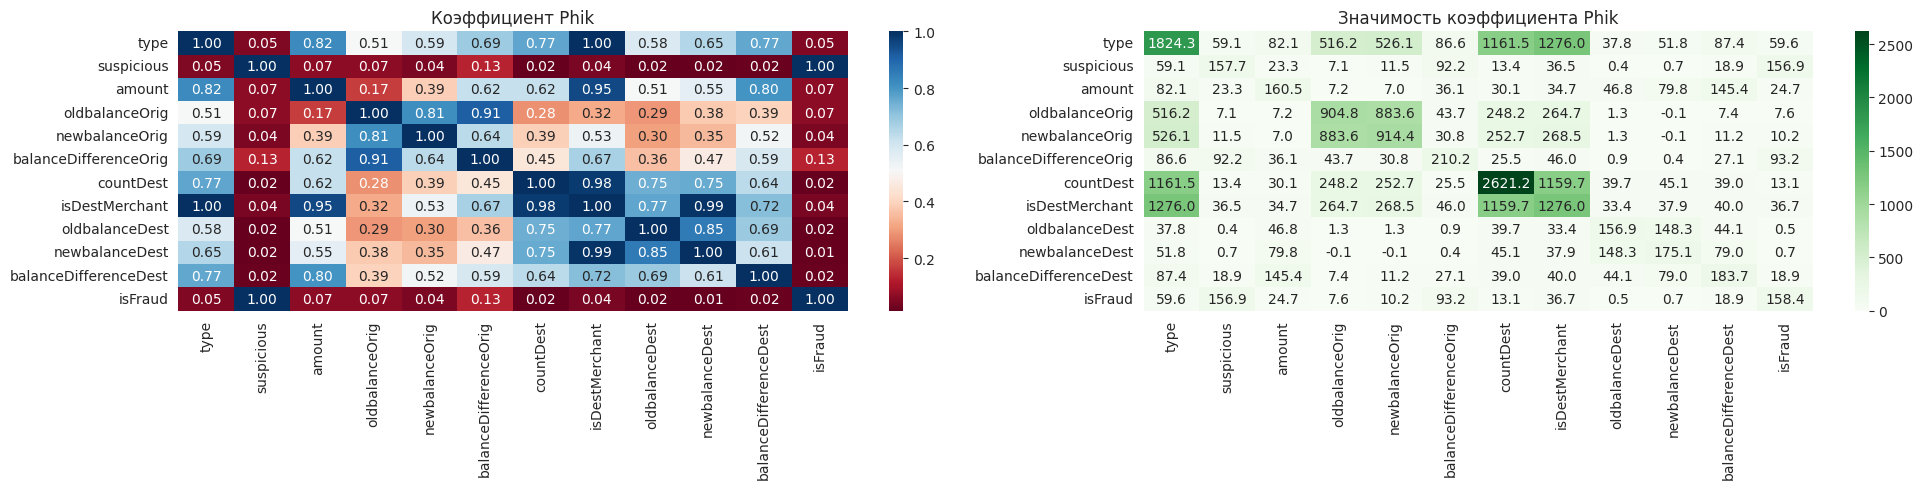

CPU times: user 32.6 s, sys: 1.77 s, total: 34.3 s
Wall time: 1min 14s


In [ ]:
%%time
df_test_pandas = df_test.to_pandas()
phik_matrix_test = df_test_pandas.phik_matrix(
    interval_cols=number_columns,
    quantile=True
)
significance_matrix_test = df_test_pandas.significance_matrix(
    interval_cols=number_columns
)
plot_phik(phik_matrix_test, significance_matrix_test)

Итак, так как матрицы получились очень схожие, то и вывод о них можно сделать общий. Очень высокие корреляции показали следующие пары признаков:
- Тип транзакции и то, является ли получатель торговцем - очевидно для торговцев характерен определённый тип транзакции -скорее всего это будет перевод на их карту
- Подозрительные транзакции и мошеннические транзакции (целевая переменная) - ну тут признак явно сильно коррелирует с целевой переменной и это было показано ранее
- Сумма транзакции и то, является ли получатель торговцем - очевидно, торговцы получают достаточно крупные сумму денег от своих клиентов
- Старый баланс полчателя и раница между балансами получателя - видимо часто новый баланс получателя получался низким или вообще нулевым
- То, является ли получатель торговцем и количество переводов получателю - что ж, видимо хорошо у торговцев идут дела - много переводов получают
- Новый баланс получателя и то, является ли получатель торговцем - следствие предыдущего пункта (там видимо и суммы переводов неплохие)

Итак, разделим данные на предикторы и целевую переменную

In [ ]:
X_train, y_train = df_train.drop('isFraud'), df_train['isFraud']
X_valid, y_valid = df_valid.drop('isFraud'), df_valid['isFraud']
X_test, y_test = df_test.drop('isFraud'), df_test['isFraud']

Закодируем категориальный столбец типа перевода с помощью CatBoost-кодировщика

In [ ]:
catboost_encoder = CatBoostEncoder()
train_encoded = catboost_encoder.fit_transform(
    X_train.select(categorical_columns).to_pandas(),
    y_train.to_pandas()
)
X_train = X_train.with_columns(
    [pl.Series(column, train_encoded[column]) for column in categorical_columns]
)

valid_encoded = catboost_encoder.transform(
    X_valid.select(categorical_columns).to_pandas(),
    y_valid.to_pandas()
)
X_valid = X_valid.with_columns(
    [pl.Series(column, valid_encoded[column]) for column in categorical_columns]
)

test_encoded = catboost_encoder.transform(
    X_test.select(categorical_columns).to_pandas(),
    y_test.to_pandas()
)
X_test = X_test.with_columns(
    [pl.Series(column, test_encoded[column]) for column in categorical_columns]
)

Нормируем нащи данные (пригодится в дальнейшем для генерации новых данных)

In [ ]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train.to_pandas())
column_names = scaler.get_feature_names_out()
X_train = X_train.with_columns(
    [
        pl.Series(column, train_scaled[:, index]) for \
        index, column in enumerate(column_names)
    ]
)

valid_scaled = scaler.fit_transform(X_valid.to_pandas())
X_valid = X_valid.with_columns(
    [
        pl.Series(column, valid_scaled[:, index]) for \
        index, column in enumerate(column_names)
    ]
)

test_scaled = scaler.fit_transform(X_test.to_pandas())
X_test = X_test.with_columns(
    [
        pl.Series(column, test_scaled[:, index]) for \
        index, column in enumerate(column_names)
    ]
)

# Обучение моделей

Итак, переходим к обучению моделей. В качестве базового алгоритма для всех дальнейших способов обучения будет выступать CatBoostClassifier, к которому затем будет применена калибровка вероятностей

Для каждой модели с помощью Optuna будут подбираться оптимальные гиперпараметры, максимизирующие метрику $\large{F\beta}$:
$$\large{F\beta=\frac{(1+\beta^2)\cdot precision \cdot recall}{\beta^2\cdot precision + recall}}$$

Для задачи с сильным дизбалансом классов обычно ставят $\large{beta}=2$, я решил не выбиваться из общего ряда и сделать также

Ещё дополнительно на валидации будет подбираться пороговое значение перевода вероятносей в классы, также максимизирующее метрику $\large{F\beta}$

In [ ]:
def get_stats(
    X_train,
    y_train,
    param_distributions,
    default_params,
    beta=2,
    epsilon=1e-10
):
    estimator = CatBoostClassifier(**param_distributions, **default_params)
    estimator.fit(X_train, y_train)
    model = CalibratedClassifierCV(
        estimator=estimator,
        cv='prefit',
        method='isotonic'
    )
    model.fit(X_valid, y_valid)
    y_valid_probs = model.predict_proba(X_valid)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(
        y_valid,
        y_valid_probs
    )
    fbeta = (1 + beta ** 2) * (precisions * recalls) / \
        ((beta ** 2 * precisions) + recalls + epsilon)
    index = np.nanargmax(fbeta)
    return model, thresholds[index], fbeta[index]

def objective(trial, X_train, y_train, beta=2, epsilon=1e-10, **default_params):
    param_distributions = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'depth': trial.suggest_int('depth', 2, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 1, step=1e-3),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1, step=1e-3),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50)
    }
    fbeta = get_stats(
        X_train,
        y_train,
        param_distributions,
        default_params,
        beta=beta,
        epsilon=epsilon
    )[-1]
    return fbeta

def optimize(
    X_train,
    y_train,
    n_trials=20,
    beta=2,
    epsilon=1e-10,
    **default_params
):
    study = create_study(
        direction='maximize',
        sampler=TPESampler(seed=random_state),
        study_name=f'Оптимизация алгоритма CatBoost'
    )
    set_verbosity(WARNING)
    study.optimize(
        lambda trial: objective(trial, X_train, y_train, **default_params),
        show_progress_bar=True,
        n_trials=n_trials
    )
    model, threshold = get_stats(
        X_train,
        y_train,
        study.best_params,
        default_params,
        beta=beta,
        epsilon=epsilon
    )[:2]
    return model, threshold

Напишем функцию для получения предсказаний и вероятностей из иодели по найденному пороговому значению

In [ ]:
def get_probs_and_preds(model, threshold, X_true, name):
    y_probs = pl.Series(
        name,
        model.predict_proba(X_true)[:, 1],
    )
    y_preds = (y_probs >= threshold).cast(int)
    return y_probs, y_preds

Напишем функцию для отрисовки кривых precision-recall для всех 3 выборок, а также матриц ошибок (опять-таки, для всех 3 выборок)

In [ ]:
def plot_metrics(model, threshold, figsize=(12, 7)):
    axis = plt.subplots(nrows=2, ncols=2, figsize=figsize)[1]
    axis = axis.flatten()
    for X, y, color, title, ax in zip(
        [X_train, X_valid, X_test],
        [y_train, y_valid, y_test],
        ['blue', 'orange', 'green'],
        ['Train', 'Valid', 'Test'],
        [axis[1], axis[2], axis[3]]
    ):
        y_probs, y_preds = get_probs_and_preds(model, threshold, X, y.name)
        precisions, recalls, thresholds = precision_recall_curve(y, y_probs)
        pr_auc = auc(recalls, precisions)
        ap_score = average_precision_score(y, y_probs)
        axis[0].plot(
            recalls,
            precisions,
            label=(
                f'{title}: PR-AUC = {pr_auc:.3f}' + \
                f'(Average precision = {ap_score:.3f})'
            ),
            color=color
        )
        ConfusionMatrixDisplay.from_predictions(
            y_true=y,
            y_pred=y_preds,
            display_labels=[0, 1],
            cmap='Greens',
            ax=ax
        )
    axis[0].set_xlabel('Recall')
    axis[0].set_ylabel('Precision')
    axis[0].set_title('Precision-Recall (PR) Кривая')
    axis[0].legend(loc='lower left')
    axis[1].set_title('Train')
    axis[2].set_title('Valid')
    axis[3].set_title('Test')
    for ax in axis[1:]:
        ax.set_xlabel('Предсказания')
        ax.set_ylabel('Истина')
    plt.tight_layout()
    plt.show()

Напишем функция для подсчёта следующих метрик:
- accuracy
- precision
- recall
- $\large{F\beta}$

In [ ]:
def get_metrics(model, threshold, title, beta=2, metrics=None):
    y_test_preds = get_probs_and_preds(model, threshold, X_test, y_test.name)[1]
    new_df = pl.DataFrame({
        'title': [title],
        'accuracy': [accuracy_score(y_test, y_test_preds)],
        'precision': [precision_score(y_test, y_test_preds)],
        'recall': [recall_score(y_test, y_test_preds)],
        'fbeta': [fbeta_score(y_test, y_test_preds, beta=beta)]
    })
    if metrics is not None:
        metrics = pl.concat([metrics, new_df])
    else:
        metrics = new_df
    return metrics

Напишем функцию для отрисовки важноси признаков из модели CatBoost

In [ ]:
def plot_feature_importances(
    model,
    columns,
    palette='RdBu',
    rotation=45,
    figsize=(12, 5)
):
    ax = plt.subplots(figsize=figsize)[1]
    importance_df = pl.DataFrame({
        'importance': model.estimator.feature_importances_,
        'column': columns
    }).sort('importance', descending=True)
    importances, columns = importance_df['importance'], importance_df['column']
    sns.barplot(x=columns, y=importances, palette=palette, ax=ax)
    for container in ax.containers:
        ax.bar_label(container)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation)
    plt.show()

## Обычный CatBoost

Запустим подбор оптимальных гиперпараметров

In [ ]:
model, threshold = optimize(
    X_train,
    y_train,
    n_trials=10,
    random_state=random_state,
    verbose=False
)
threshold

[I 2026-08-25 07:18:02,006] A new study created in memory with name: Оптимизация алгоритма CatBoost


  0%|          | 0/10 [00:00<?, ?it/s]

np.float64(0.8333333333333334)

Итак, оптимальный найденный порог для перевода вероятностей в классы - $\large{\frac{5}{6}}$

Визуализируем метрики

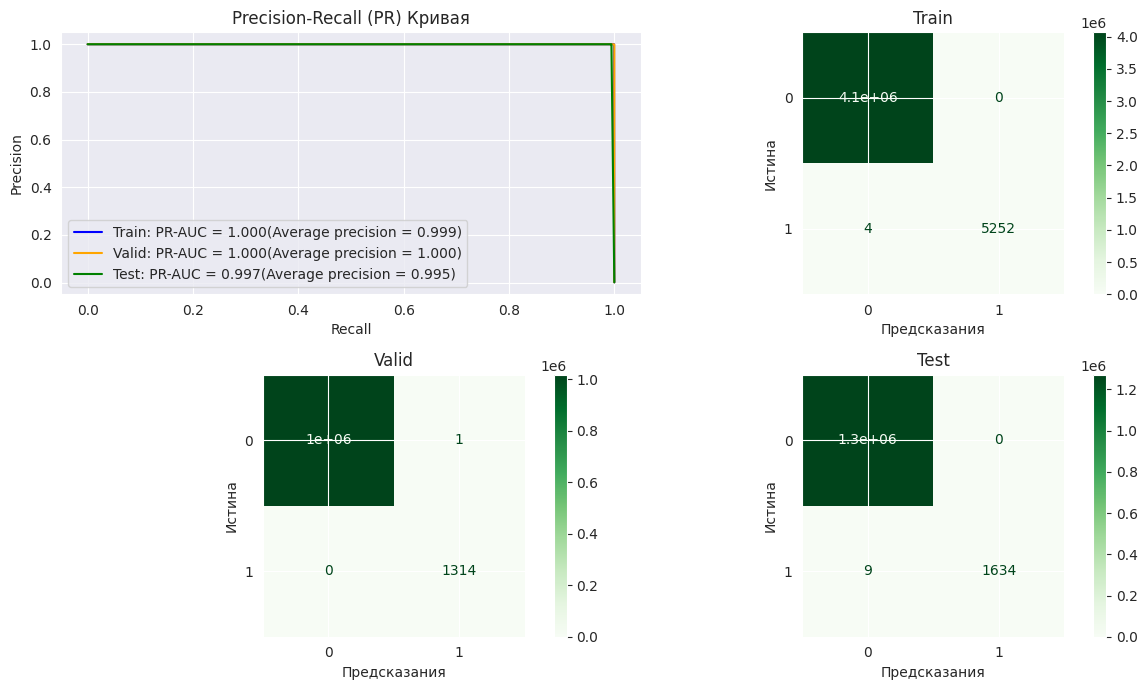

In [ ]:
plot_metrics(model, threshold)

Итак, видим следующее:
- Все значения PR-AUC не меньше 0.995
- На валидации все мошеннические транзакции были предсказаны верно и лишь одна обычная транзакция была предсказан мошеннической
- На тесте из 1643 транзакций были пропущены 9 и ни одна обычная транзакция не была предсказана мошеннической

Визуализируем важность признаков

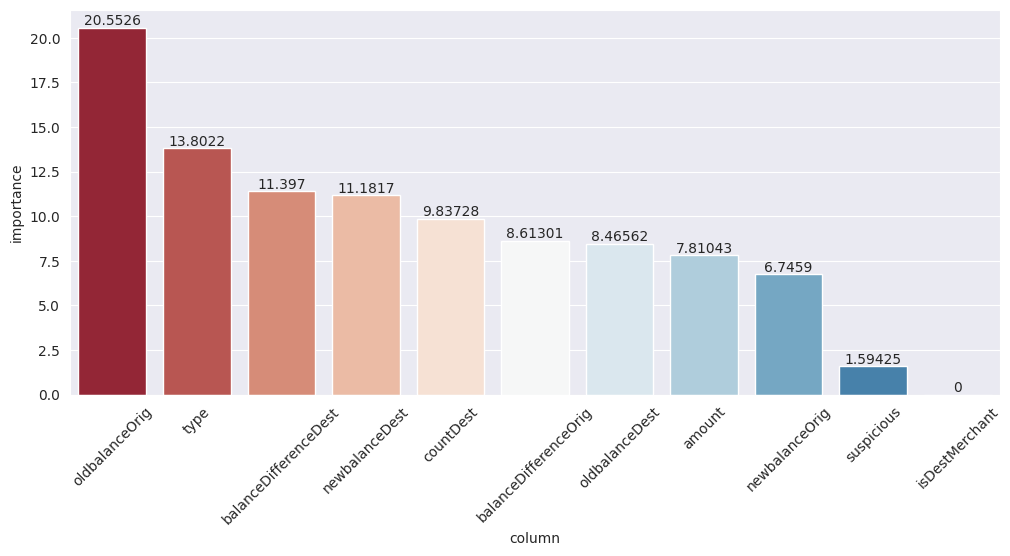

In [ ]:
plot_feature_importances(model, X_train.columns)

Получим значения метрик

In [ ]:
metrics = get_metrics(model, threshold, 'Default')

## Over-sampling

Итак, мы подошли к идее over-sampling - генерации новых данных минорного класса, чтобы итоговое число этих объектов равнялось числу объектов мажоритарного класса

В качестве алгоритма я буду использовать ADASYN (adaptive synthetic sampling). Основная идея алгоритма заключается втом, чтобы генерировать больше синтетических примеров там, где алгоритму труднее всего выучиться, а именно в областях, плотно окружённых мажоритарным классом

Идея алгоритма следующая:

Сначала определяем степень дизбаланса классов:
$$\large{d=\frac{m_s}{m_l},}$$
где:
- $\large{m_s}$ - число объектов минорного класса
- $\large{m_l}$ - число объектов мажоритарного класса

Если $\large{d}$ меньше заданного порога (обычно это 1), то алгоритм продолджает работу

Следующий шаг - определение, сколько всего синтетических примеров нужно сгенерировать:
$$\large{G=(m_l - m_s)\beta,}$$
где:
- $\large{\beta \in [0, 1]}$ - желаемый уровень баланса классов после ресэмплинга

Далее для каждого объекта минорного класса нужно посчитать "сложность" его окрестности. Для этого находим его $\large{K}$ ближайших соседей среди всех объектов датасета и считаем следующее отношение:
$$\large{r_i=\frac{\Delta_i}{K},}$$
где:
- $\large{\Delta_i}$ - число объектов мажоритарного класса среди $\large{K}$ соседей

Чем выше $\large{r_i}$, тем более объет окружён мажоритарным классом и тем сложнее для классифкатора провести границу в этой области

Затем нормируем показатели $\large{r_i}$ чтобы они означали вероятности того, что объект $\large{x_i}$ надо использовать для сэмплирования:
$$\large{\hat{r}_i=\frac{r_i}{\sum_{j=1}^{m_s}r_j}}$$

Теперь надо определить, сколько синтетических примеров генерировать для каждого объекта $\large{x_i}$:
$$\large{g_i=\hat{r}_i\cdot G}$$

Адаптивность метода и заключается в том, что объекты с высоким $\large{\hat{r}_i}$ (преимущественно окружённые мажоритарным классом) получают больше синтетических клонов

Ну и финальный шаг - генерация. Для каждого объекта $\large{x_i}$ генерируем $\large{g_i}$ новых точек - выбираем случайного соседа $\large{x_j}$ из минорного класса и интерполируем:
$$\large{x_{new}=x_i+\lambda(x_j-x_i), \quad \lambda \sim U(0, 1)}$$

Плюсом алгоритма является то, что фокус на пограничных случаях может улучшить разделяющую способность модели именно там, где объекты мажоритарного и минорного классов похожи друг на друга, а это самые ценные случаи

Минус вытекает из адаптивности алгоритма - если какие-то объекты минаорного класса шумовые или выбросы (и они при этом окружены мажоритарным классом), то алгоритм будет генерировать вокруг них особенно много синтетических точек, непропорционально усиливая итак имеющийся шум

In [ ]:
%%time
adasyn = ADASYN(random_state=random_state)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(
    X_train.to_numpy(),
    y_train.to_numpy()
)
X_train_adasyn = pl.DataFrame(X_train_adasyn, schema=X_train.schema)
y_train_adasyn = pl.Series(y_train.name, y_train_adasyn)

CPU times: user 30.3 s, sys: 1.97 s, total: 32.3 s
Wall time: 34.6 s


In [ ]:
%%time
model_adasyn, threshold_adasyn = optimize(
    X_train_adasyn,
    y_train_adasyn,
    n_trials=10,
    random_state=random_state,
    verbose=False
)
threshold_adasyn

  0%|          | 0/10 [00:00<?, ?it/s]

CPU times: user 1h 34min 30s, sys: 2min 1s, total: 1h 36min 32s
Wall time: 57min 10s


np.float64(0.2)

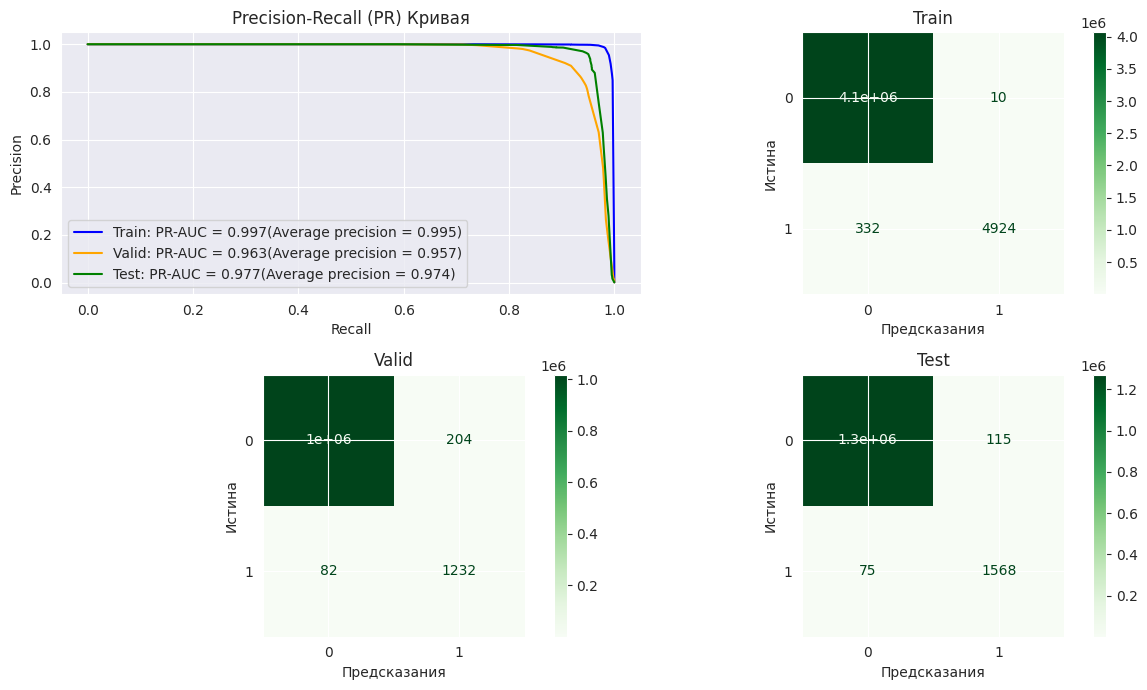

In [ ]:
plot_metrics(model_adasyn, threshold_adasyn)

Итак, видим следующее:
- Все значения PR-AUC не меньше 0.957, что довольно сильно хуже предыдущего случая
- На валидации примерно 6% мошеннических транзакций не было задетектировано, и 15,5% от исходного количества истинных мошенических транзакций было помечено мошенническими по ошибке
- На тесте статистика немножко получше, чем на валидации

Видим, что CatBoost по умолчанию оказался сильно лучше того, что обучался на синтетических данных, полученных с помощью ADASYN

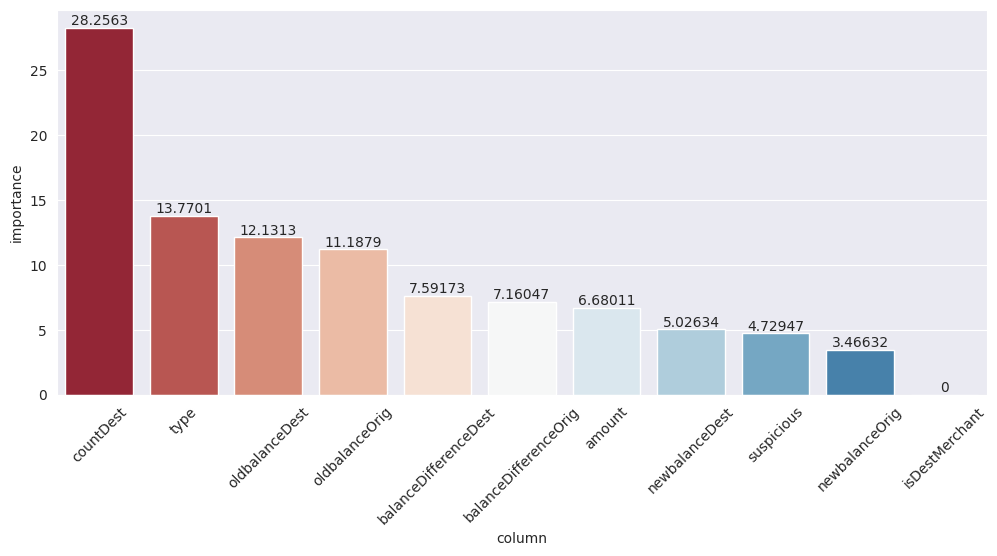

In [ ]:
plot_feature_importances(model_adasyn, X_train_adasyn.columns)

In [ ]:
metrics = get_metrics(
    model_adasyn,
    threshold_adasyn,
    'ADASYN',
    metrics=metrics
)

## Under-sampling

Теперь рассмотрим обратную технику - under-sampling. Для достижения баланса классов мы уменьшаем количество объектов мажоритарного класса. В нашем случае объём уменьшения будет значительным, ибо число нормальных транзакций уменьшится примерно с 4 миллионов до около 8 тысяч

Но начнём мы с описания не самого алгоритма уменьшения числа объектов, а с инструмента, который он использует - я имею ввиду алгоритм кластеризации mini-batch K-Means (K-means с разделением на батчи). Выбран этот алгоритм бы из-за скорости, так как почти все алгоритмы under-sampling имеют временную сложность $\large{O(N^2)}$, где $\large{N}$ - число объектов мажоритарного класса. С нашими миллионами это будет работать очень долго, поэтому нужно было придумать какое-то ускорение алгоритма

Итак, введём некоторые обозначения:
- $\large{k}$ - заданное число кластеров
- $\large{\mathcal{C}=\{c_1,c_2,...,c_k\} - центроиды кластеров}$
- $\large{v_j, \ j \in \overline{1,k}}$ - накопительный счётчик, показывающий, сколько всего объектов было отнесено к кластеру $\large{j}$ на предыдущих итерациях

Как и классический K-Means, алгоритм минимизирует суммарное квадратное отклонение (инерцию $\large{J}$):
$$\large{J(\mathcal{C})=\sum_{i=1}^N \underset{j\in\overline{1,k}}{min}\left|\left|x_i-c_j\right|\right|_2^2}$$

На первом шаге выполняется изначальная иницализация центроидов кластеров $\large{\mathcal{C}^0=\{c_1,c_2,...,c_k\}}$ и счётчики присовений зануляются для каждого класера - $\large{v_j = 0 \quad  \forall j \in \overline{1,k}}$

Далее запускается итеративный процесс:
1. Cначала из всего массива $\large{X}$ формируется подвыборка $\large{\mathcal{B}=\{x_1,x_2,...,x_b\}}$
2. Далее для каждого объекта $\large{x_m} \in \mathcal{B}$ находится индекс $\large{z_m}$ ближайшего к нему центроида:
$$\large{z_m = \underset{j\in\overline{1,k}}{\arg\min}\left|\left|x_m-c_j\right|\right|_2^2}$$
3. Далее для каждого объекта $\large{x_m}$ и его центроида под индексом $\large{j=z_m}$ выполняются 2 действия одновременно:
   - Обновляется счётчик центроида:
   $$\large{v_j\leftarrow v_j + 1}$$
   - Новое положение центроида $\large{c_j}$ рассчитывается по формуле скользящего среднего:
   $$\large{c_j \leftarrow (1 - n_j)\cdot c_j + n_j\cdot x_j,}$$
   где $\large{n_j=\frac{1}{v_j}}$

В качестве основного плюса алгоритма можно отметить его скорость по сравнению с обычным K-Means, так как обрабатывается не весь датасет целиком, а только его отдельные батчи

Из минусов же можно отметить то, что значение инерции обычно получается хуже по сравнению с K-Means из-за шума в батчах, но обычно не намного

Итак, ладно, мы обсудили алгоритм кластеризации K-Means по батчам, но как он поможет нам в исходной задаче under-sampling?

А произойдёт это следующим образом - все объекты мажоритарного класса подвергнутся процедуре кластеризации с числом кластеров, равных числу объектов минорного класса. А в качестве финальных "сэмплированных" объектов возьмутся просто центроиды кластеров - вот так всё просто

In [ ]:
%%time
cluster_centroids = ClusterCentroids(
    random_state=random_state,
    estimator=MiniBatchKMeans(batch_size=8192, random_state=random_state)
)
X_train_cluster_centroids, y_train_cluster_centroids = \
    cluster_centroids.fit_resample(X_train.to_numpy(), y_train.to_numpy())
X_train_cluster_centroids = pl.DataFrame(
    X_train_cluster_centroids,
    schema=X_train.schema
)
y_train_cluster_centroids = pl.Series(y_train.name, y_train_cluster_centroids)

CPU times: user 2min 20s, sys: 395 ms, total: 2min 21s
Wall time: 2min 16s


In [ ]:
%%time
model_cluster_centroids, threshold_cluster_centroids = optimize(
    X_train_cluster_centroids,
    y_train_cluster_centroids,
    n_trials=50,
    random_state=random_state,
    verbose=False
)
threshold_cluster_centroids

  0%|          | 0/50 [00:00<?, ?it/s]

CPU times: user 2min 40s, sys: 7.5 s, total: 2min 47s
Wall time: 1min 47s


np.float64(0.9940828402366864)

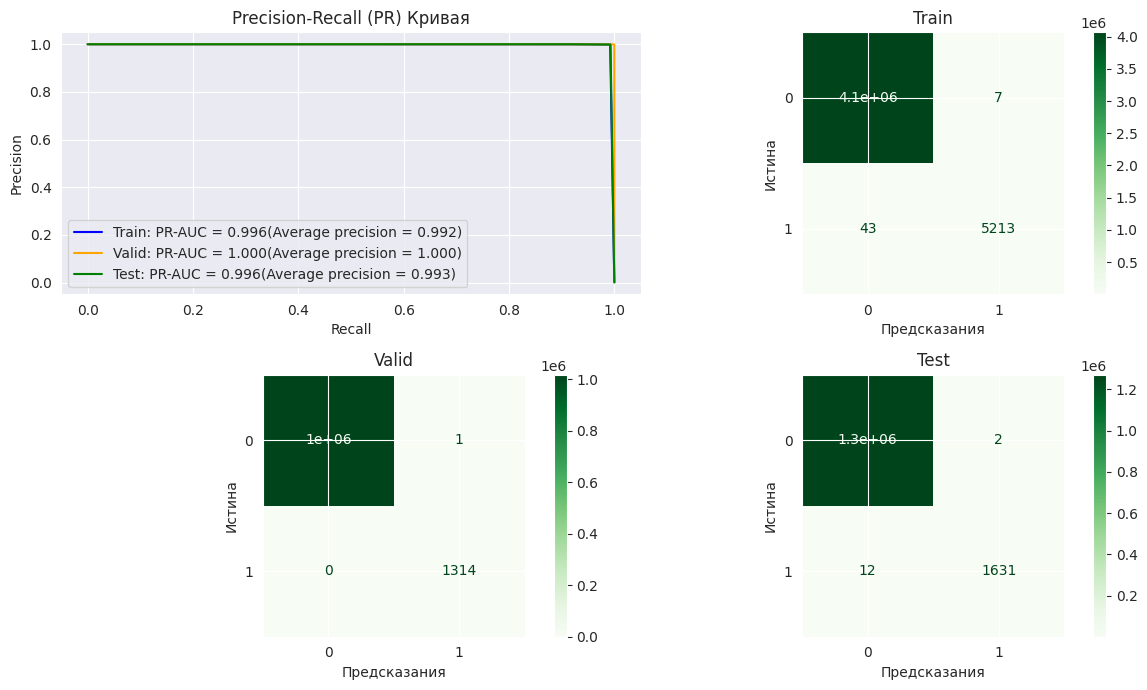

In [ ]:
plot_metrics(model_cluster_centroids, threshold_cluster_centroids)

Итак, видим следующее:
- Все значения PR-AUC не меньше 0.993
- На валидации статистика такая же, как и у обычного CatBoost
- На тесте из 1643 транзакций были пропущены 12 и лишь 2 обычнах транзакции были предсказана мошенническими по ошибке

Здесь всё почти схоже с обычным CatBoost

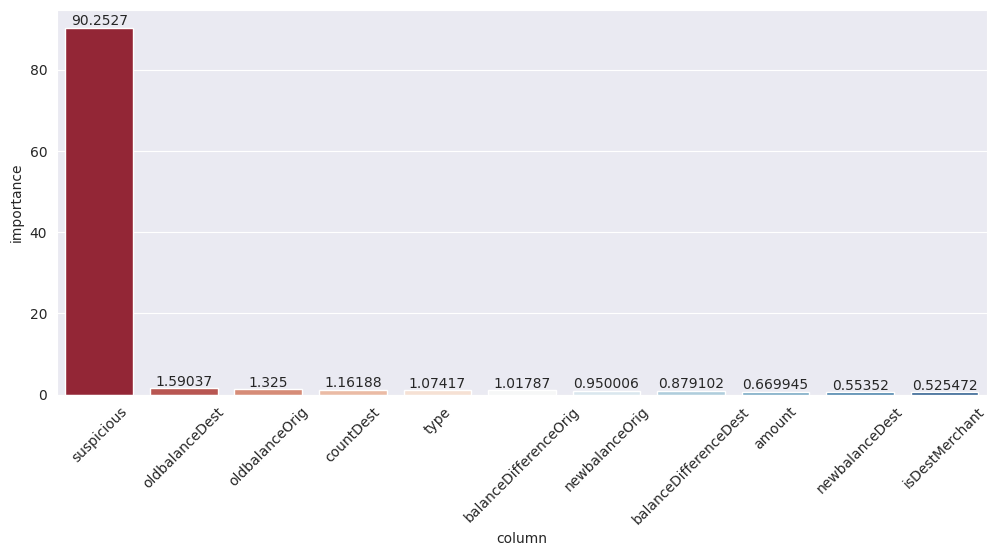

In [ ]:
plot_feature_importances(
    model_cluster_centroids,
    X_train_cluster_centroids.columns
)

In [ ]:
metrics = get_metrics(
    model_cluster_centroids,
    threshold_cluster_centroids,
    'ClusterCentroids',
    metrics=metrics
)

## Focal loss

Итак, мы уже успели обучить обычный алгоритм CatBoost, а также побаловаться с over-sampling и under-sampling для дорьбы с дисбалансом классов. Теперь же для этой борьбы попробуем порабоать на уровне функций потерь

Всго будет рассмотрено 2 функции потерь и первая из них - Focal loss:
$$\large{\mathcal{FL}(y,p)=-y\cdot\alpha\cdot(1-p)^{\gamma}\cdot\log(p)-(1-y)\cdot(1-\alpha)\cdot p^{\gamma}\cdot\log(1-p),}$$
где:
- $\large{p=\frac{1}{1+e^{-margin}}}$ - вероятность принадлежности к положительному минорному классу (в модели CatBoost $\large{margin}$ - это выучиваемый логарифм отношения шансов)
- $\large{\alpha}$ - вес положительного класса (обычно вычисляется как отношение числа объеко мажоритарного класса к числу всех объектов)
- $\large{\gamma}$ - степенной параметр, с помощью которого функция потерь занижает ошибку у объектов, которые правильно и уверенно классифицируются (если $\large{\gamma}$ положительна)

Ну, как я уже упомянул, эта функция потерь занижает вклад уверенно и правильно классифицируемых объектов и соответственно завышает у уверенно и неверно классифицируемых, то есть концентрирует на них своё внимание

Из минусов можно отметить то, что $\large{\alpha}$ и $\large{\gamma}$ приходится перебирать на валидации, так как это гиперпараметры. Плюс из-за сильного акцента на сложных примерах модель может начать сильно штрафовать себя за аномалии или ошибочно размеченные данные

В CatBoost можно передать собственноручно написанную функцию потерь, однако для этого нужно посчитать первую и вторую их производные по $\large{margin}$ и передать их отрицания в качестве результата. Рассчёт производных может быть неблагодарным и трудоёмким делом и в случае с Focal loss это именно так и есть:
$$\begin{cases}\frac{\partial\ \mathcal{FL}}{\partial \ margin} = y\alpha (1 - p)^{\gamma}\left[\gamma p\log(p) + p - 1\right]+(1 - y)(1 - \alpha) p^{\gamma}\left[p-\gamma(1 - p)\log(1 - p)\right] \\
\frac{\partial^2\ \mathcal{FL}}{\partial \ margin^2} = y\alpha p(1 - p)^{\gamma}\left[\gamma\left(1 - p(\gamma + 1)\right)\log(p)+(2\gamma + 1)(1 - p)\right]+(1 - y)(1 - \alpha)(1 - p) p^{\gamma}\left[\gamma\left(p(\gamma + 1) - \gamma\right)\log(1 - p) + (2\gamma + 1)p\right]\end{cases}$$

Класс функции потерь должен наследоваться от object и иметь реализованный метод calc_ders_range, в который подаются отступы, истинные метки и веса, а возвращаются отрицательные первые и вторые производные по объектам

In [ ]:
class FocalLoss(object):
    def __init__(self, alpha=0.25, gamma=2.0, border=1e-6, eps=1e-9):
        self.alpha = alpha
        self.gamma = gamma
        self.border = border
        self.eps = eps

    def calc_ders_range(self, approxes, targets, weights):
        approxes = np.array(approxes)
        targets = np.array(targets)

        p = np.clip(expit(approxes), self.eps, 1 - self.eps)
        q = 1 - p
        log_p = np.log(p)
        log_q = np.log(q)
        a_qg = self.alpha * q ** gamma
        b_pg = (1 - self.alpha) *  p ** gamma

        der1 = (
            targets * a_qg * (self.gamma * p * log_p - q) + \
            (1 - targets) * b_pg * (p - self.gamma * q * log_q)
        )
        der2 = (
            targets * p * a_qg * (
                gamma * (q - self.gamma * p) * log_p + (2 * self.gamma + 1) * q
            ) + \
            (1 - targets) * q * b_pg * (
                gamma * (p - self.gamma * q) * log_q + (2 * self.gamma + 1) * p
            )
        )
        der2 = np.maximum(der2, self.border)

        if weights is not None:
            weights = np.array(weights)
            der1 *= weights
            der2 *= weights

        return list(zip(-der1, -der2))

Также если пользователь определил свою фыункцию птерь, то обязательно нужно будет передать в конструктор класса аргумент eval_metric (оценивающую метрику, по которой будет осуществляться ранняя остановка обучения). В моём случае это будет площадь под кривой Precision-recall (PR-AUC)

In [ ]:
%%time
alpha, gamma = y_train.filter(y_train == 0).shape[0] / y_train.shape[0], 2
focal_loss = FocalLoss(alpha=alpha, gamma=gamma)

model_focal, threshold_focal = optimize(
    X_train,
    y_train,
    n_trials=10,
    loss_function=focal_loss,
    eval_metric='PRAUC',
    random_state=random_state,
    verbose=False
)
threshold_focal

  0%|          | 0/10 [00:00<?, ?it/s]

CPU times: user 3h 23min 36s, sys: 22min 58s, total: 3h 46min 34s
Wall time: 3h 19min 52s


np.float64(0.9375)

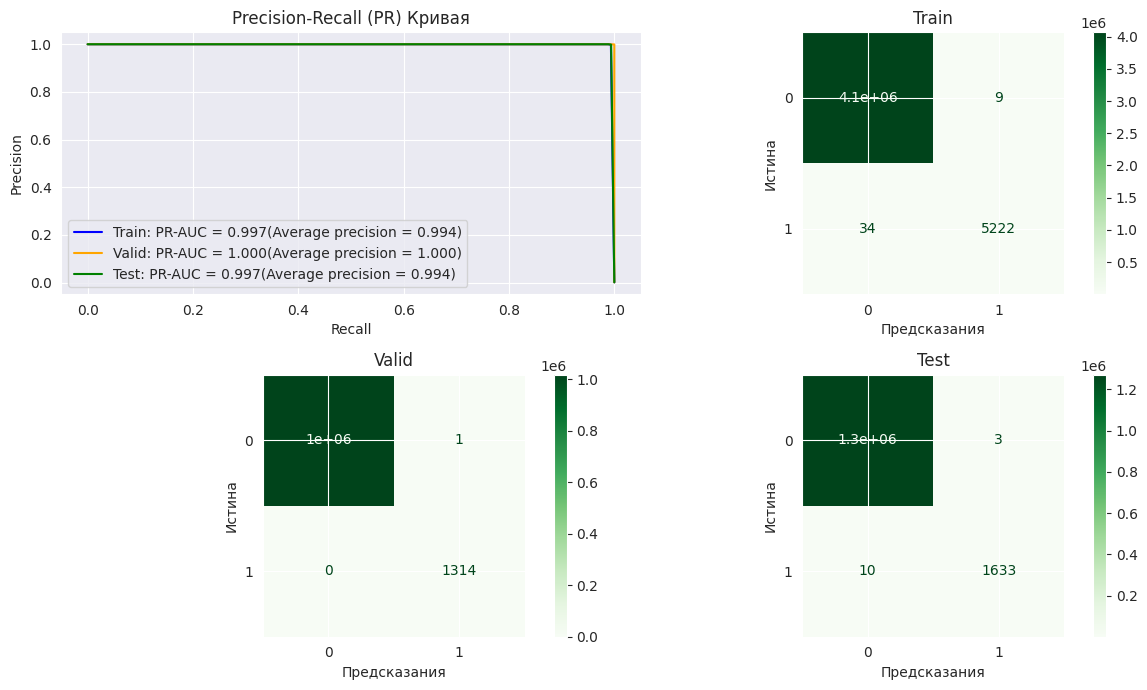

In [ ]:
plot_metrics(model_focal, threshold_focal)

Итак, видим следующее:
- Все значения PR-AUC не меньше 0.994
- На валидации все мошеннические транзакции были предсказаны верно и лишь одна обычная транзакция была предсказан мошеннической
- На тесте из всех транзакций из 1643 были пропцшены 10 и лишь 3 обычнах транзакции были предсказаны мошенническими по ошибке

Здесь также всё очень сильно похоже на обычный CatBoost

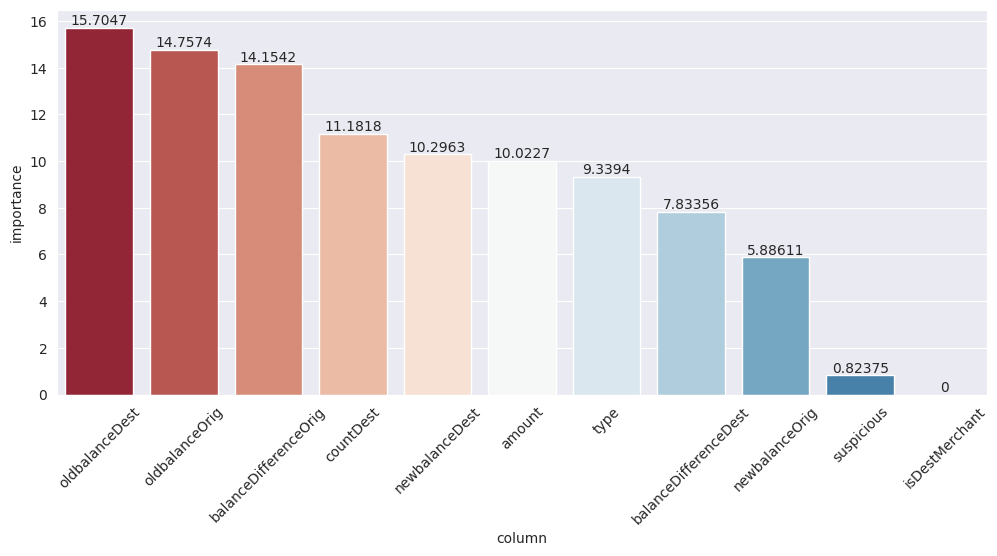

In [ ]:
plot_feature_importances(model_focal, X_train.columns)

In [ ]:
metrics = get_metrics(
    model_focal,
    threshold_focal,
    'Focal loss',
    metrics=metrics
)

## Dice loss

Вторая такая функция потерь, борющаяся с дизабалансом - Dice loss:
$$\large{\mathcal{DL}=1 - \frac{2\sum_{i=1}^N y_i\cdot p_i + \epsilon}{\sum_{i=1}^N(y_i + p_i) + \epsilon},}$$
где:
- $\large{\epsilon}$ - малый вспомогательный параметр для избежания деления на 0

Функция сфокусирована на максимизации пересечения предсказанных и реальных объектов минорного класса

Из плюсов можно отметить то, что огромный пласт объектов мажоритарного класса почти не создаёт градиентого давления на модель. Также отсутствует необходимость подбирать гиперпараметры

Минусы у данной функции потерь тоже присутствтуют. Во-первых это сложный и невыпуклый ландшафт оптимизации - вторая производная может становится отрицательной и нужно насильно её делать положительной. Также функция склонна к переобучению на шуме

Введём некоторые обозначения:
$$\large{\begin{cases}
A = 2\sum_{i=1}^N y_i\cdot p_i + \epsilon \\
B = \sum_{i=1}^N(y_i+p_i) + \epsilon
\end{cases}}$$

Тогда производные выглядят значительн приятнее для глаза, чем в предыдущем случае:
$$\large{\begin{cases}
\frac{\partial\ \mathcal{DL}}{\partial\ margin_i} = \frac{A - 2y_iB}{B^2}p_i(1-p_i) \\
\frac{\partial^2\ \mathcal{DL}}{\partial\ margin^2_i} = \frac{A - 2y_iB}{B^2}p_i(1-p_i)\left(1-2p_i\left(1+\frac{1-p_i}{B}\right)\right)
\end{cases}}$$

In [ ]:
class DiceLoss(object):
    def __init__(self, border=1e-6, eps=1e-9):
        self.border = border
        self.eps = eps

    def calc_ders_range(self, approxes, targets, weights):
        approxes = np.array(approxes)
        targets = np.array(targets)
        p = expit(approxes)

        A = 2 * np.sum(targets * p) + self.eps
        B = np.sum(targets + p) + self.eps

        der1 = (A - 2 * targets * B) * p * (1 - p) / B ** 2
        der2 = der1 * (1 - 2 * p * (1 + (1 - p) / B))
        der2 = np.maximum(der2, self.border)

        if weights is not None:
            weights = np.array(weights)
            der1 *= weights
            der2 *= weights

        return list(zip(-der1, -der2))

In [ ]:
%%time
dice_loss = DiceLoss()

model_dice, threshold_dice = optimize(
    X_train,
    y_train,
    n_trials=10,
    loss_function=dice_loss,
    eval_metric='PRAUC',
    random_state=random_state,
    verbose=False
)
threshold_dice

  0%|          | 0/10 [00:00<?, ?it/s]

CPU times: user 2h 51min 46s, sys: 20min 55s, total: 3h 12min 42s
Wall time: 2h 53min 3s


np.float64(0.9926470588235294)

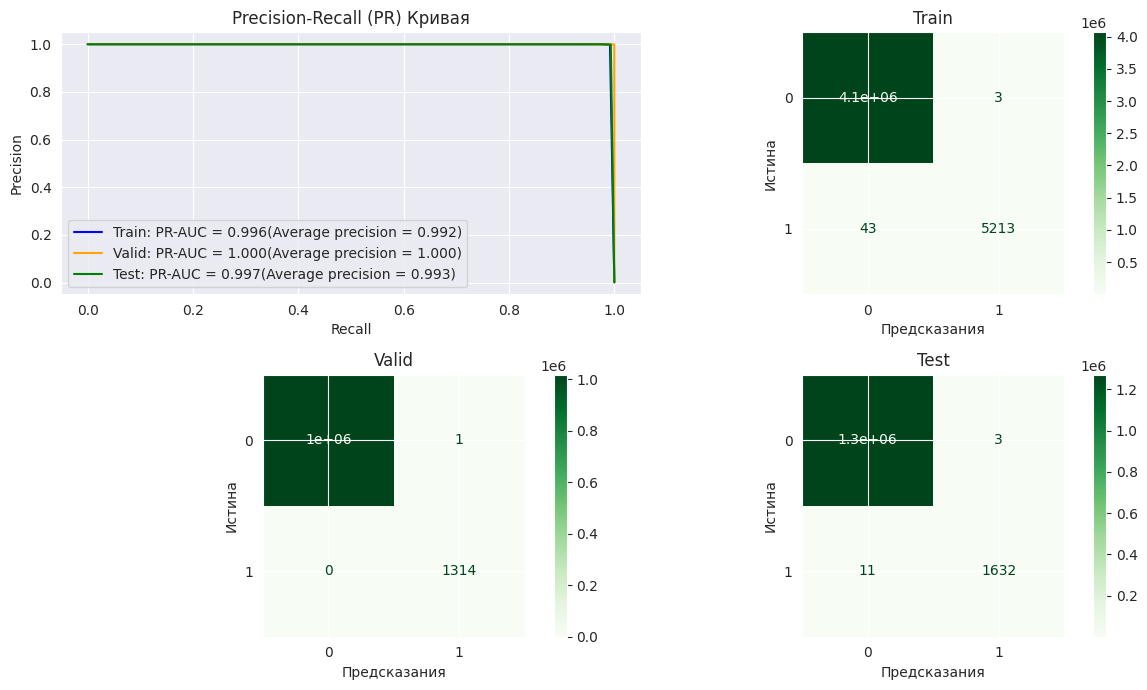

In [ ]:
plot_metrics(model_dice, threshold_dice)

Итак, видим следующее:
- Все значения PR-AUC не меньше 0.992
- На валидации все мошеннические транзакции были предсказаны верно и лишь одна обычная транзакция была предсказан мошеннической
- На тесте из всех транзакций из 1643 были пропцшены 11 и лишь 3 обычных транзакции было предсказано как мошеннические по ошибке

Цифры почти не отлшичаются от случая Focal loss

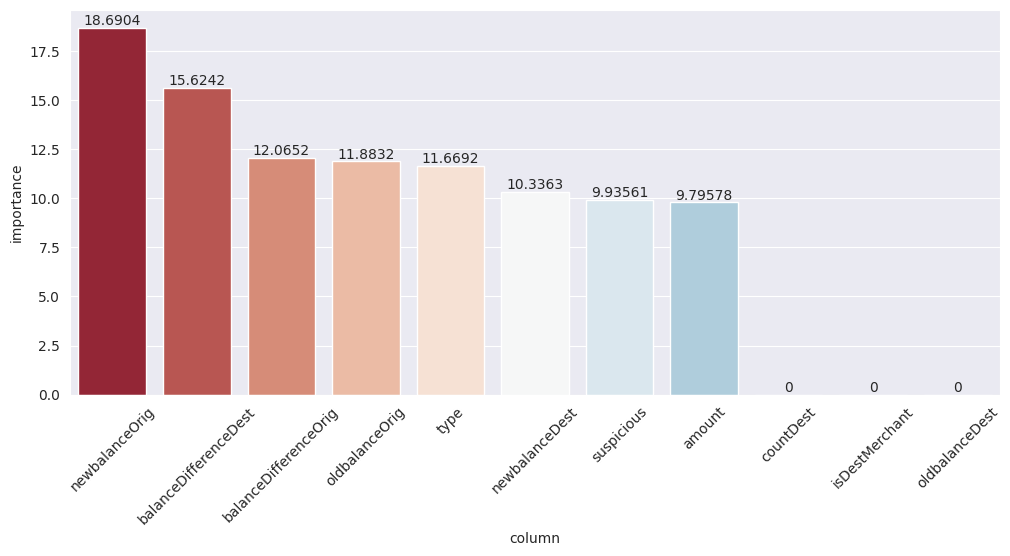

In [ ]:
plot_feature_importances(model_dice, X_train.columns)

In [ ]:
metrics = get_metrics(
    model_dice,
    threshold_dice,
    'Dice loss',
    metrics=metrics
)

# Выводы

Посмотрим на значения метрик

In [ ]:
metrics

title,accuracy,precision,recall,fbeta
str,f64,f64,f64,f64
"""Default""",0.999993,1.0,0.994522,0.995613
"""ADASYN""",0.999851,0.93167,0.954352,0.949727
"""ClusterCentroids""",0.999989,0.998775,0.992696,0.993906
"""Focal loss""",0.99999,0.998166,0.993914,0.994761
"""Dice loss""",0.999989,0.998165,0.993305,0.994273


Можно сделать следующие выводы:
- В целом, обыкновенного CatBoost с подбором порогов оказалось достаточно для достижения высокого качества, которое оказалось ещё и наилучшим
- Единственный метод, выбиывающийся из ряда - это CatBoost, обученный на синтетических данных, полученных с помощью ADASYN. С другой стороны, это единственный алгоритм, где распределения ошибок на всех трёх выборках совпадают
- В целом, модификация функции потерь по сравнерию с сэмплированием немного уменьшили precision, зато увеличили recall и их значенения метрики $\large{F\beta}$ оказались выше